In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [3]:
import pandas as pd

# 붓꽃 데이터 세트를 로딩합니다. 
iris = load_iris()

# iris.data는 Iris 데이터 세트에서 피처(feature)만으로 된 데이터를 numpy로 가지고 있습니다. 
iris_data = iris.data

# iris.target은 붓꽃 데이터 세트에서 레이블(결정 값) 데이터를 numpy로 가지고 있습니다. 
iris_label = iris.target
print('iris target값:', iris_label)
print('iris target명:', iris.target_names)

# 붓꽃 데이터 세트를 자세히 보기 위해 DataFrame으로 변환합니다. 
iris_df = pd.DataFrame(data=iris_data, columns=iris.feature_names)
iris_df['label'] = iris.target
iris_df.head(3)

iris target값: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
iris target명: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


###  붓꽃(Iris) 데이터 로딩 및 DataFrame 생성

- `load_iris()`를 통해 대표적인 머신러닝 예제 데이터인 **Iris 데이터셋**을 불러옴
- `iris.data`에는 꽃의 **피처(feature)** 정보가 numpy 배열 형태로 저장됨
  - (꽃받침 길이, 너비 / 꽃잎 길이, 너비)
- `iris.target`에는 각 데이터의 **정답(label)** 이 저장됨 (0, 1, 2)
- `iris.target_names`를 통해 각 label이 의미하는 클래스 이름 확인 가능

---

###  DataFrame으로 변환

- `pd.DataFrame()`을 사용하여 numpy 데이터를 **pandas DataFrame 형태로 변환**
- `columns=iris.feature_names`를 통해 각 피처 이름을 컬럼으로 지정
- `iris_df['label']`을 추가하여 정답(label) 컬럼 생성

---

###  데이터 확인

- `head(3)`을 통해 상위 3개 데이터 확인
- → 데이터 구조 및 값이 제대로 들어갔는지 빠르게 검증 가능

---

###  핵심 정리

- 머신러닝에서는  
   **피처(feature) + 레이블(label)** 구조로 데이터가 구성됨  
- numpy → pandas로 변환하면  
   데이터 분석 및 시각화가 훨씬 편리해짐

In [4]:
X_train, X_test, y_train, y_test = train_test_split(iris_data, iris_label, 
                                                    test_size=0.2, random_state=11)

In [5]:
# DecisionTreeClassifier 객체 생성 
dt_clf = DecisionTreeClassifier(random_state=11)

# 학습 수행 
dt_clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,11
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [6]:
# 학습이 완료된 DecisionTreeClassifier 객체에서 테스트 데이터 세트로 예측 수행. 
pred = dt_clf.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score
print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test,pred)))

예측 정확도: 0.9333


###  데이터 분리 및 모델 학습 (Decision Tree)

- `train_test_split()`을 사용하여 데이터를 **학습용(train)과 테스트용(test)**으로 분리
  - `test_size=0.2` → 전체 데이터의 20%를 테스트 데이터로 사용
  - `random_state=11` → 결과 재현을 위한 고정값

---

###  Decision Tree 모델 생성 및 학습

- `DecisionTreeClassifier` 객체 생성
- `fit(X_train, y_train)`을 통해 **학습 데이터로 모델 훈련**
  - X: 입력 데이터 (feature)
  - y: 정답 데이터 (label)

---

###  예측 수행

- `predict(X_test)`를 통해 테스트 데이터에 대한 예측값 생성
- 학습된 모델이 새로운 데이터에 대해 어떤 결과를 내는지 확인하는 과정

---

###  모델 평가 (정확도)

- `accuracy_score(y_test, pred)`를 사용하여 모델 성능 평가
  - 실제 값(`y_test`)과 예측 값(`pred`)을 비교
- 정확도는 **전체 데이터 중 맞춘 비율**을 의미

---

###  핵심 정리

- 머신러닝 기본 흐름  
   데이터 분리 → 모델 학습 → 예측 → 성능 평가

- `random_state`를 고정하는 이유  
   실행할 때마다 동일한 결과를 얻기 위해

- 정확도(Accuracy)는 가장 기본적인 평가 지표지만  
   데이터 불균형이 있을 경우 한계가 있음

In [8]:
from sklearn.datasets import load_iris

iris_data = load_iris()
print(type(iris_data))


<class 'sklearn.utils._bunch.Bunch'>


In [9]:
keys = iris_data.keys()
print('붓꽃 데이터 세트의 키들:', keys)


붓꽃 데이터 세트의 키들: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [10]:
print('\n feature_names 의 type:',type(iris_data.feature_names))
print(' feature_names 의 shape:',len(iris_data.feature_names))
print(iris_data.feature_names)

print('\n target_names 의 type:',type(iris_data.target_names))
print(' feature_names 의 shape:',len(iris_data.target_names))
print(iris_data.target_names)

print('\n data 의 type:',type(iris_data.data))
print(' data 의 shape:',iris_data.data.shape)
print(iris_data['data'])

print('\n target 의 type:',type(iris_data.target))
print(' target 의 shape:',iris_data.target.shape)
print(iris_data.target)



 feature_names 의 type: <class 'list'>
 feature_names 의 shape: 4
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

 target_names 의 type: <class 'numpy.ndarray'>
 feature_names 의 shape: 3
['setosa' 'versicolor' 'virginica']

 data 의 type: <class 'numpy.ndarray'>
 data 의 shape: (150, 4)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0

### 📌 Iris 데이터셋 구조 확인

- `load_iris()`를 통해 불러온 데이터는 **Bunch 객체** 형태
  - → 딕셔너리(dictionary)처럼 key-value 구조로 이루어짐

- `keys()`를 통해 데이터셋이 어떤 요소로 구성되어 있는지 확인
  - 주요 키: `data`, `target`, `feature_names`, `target_names` 등

---

### 📌 feature_names (피처 이름)

- 데이터의 각 컬럼이 무엇을 의미하는지 나타냄
- 총 4개의 피처 존재
  - sepal length (꽃받침 길이)
  - sepal width (꽃받침 너비)
  - petal length (꽃잎 길이)
  - petal width (꽃잎 너비)

---

### 📌 target_names (클래스 이름)

- 붓꽃의 종류(클래스) 이름을 나타냄
- 총 3개의 클래스 존재
  - setosa
  - versicolor
  - virginica

---

### 📌 data (피처 데이터)

- 실제 입력 데이터 (feature 값)
- numpy 배열 형태이며 shape은 `(150, 4)`
  - 150개 데이터
  - 4개의 피처

---

### 📌 target (레이블 데이터)

- 각 데이터의 정답(label)
- numpy 배열 형태이며 shape은 `(150,)`
- 값은 0, 1, 2로 구성됨 (각 클래스에 대응)

---

### 💡 핵심 정리

- sklearn 데이터 구조  
  👉 `data` (입력값) + `target` (정답)

- Bunch 객체는  
  👉 딕셔너리처럼 접근 가능 (`iris_data['data']`)

- 머신러닝에서 가장 기본 구조  
  👉 Feature(입력) / Label(정답) 구분이 핵심

In [11]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
dt_clf = DecisionTreeClassifier()
train_data = iris.data
train_label = iris.target
dt_clf.fit(train_data, train_label)

# 학습 데이터 셋으로 예측 수행
pred = dt_clf.predict(train_data)
print('예측 정확도:',accuracy_score(train_label,pred))

예측 정확도: 1.0


In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

dt_clf = DecisionTreeClassifier( )
iris_data = load_iris()

X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, 
                                                    test_size=0.3, random_state=121)





In [13]:
dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)
print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test,pred)))

예측 정확도: 0.9556


###  전체 데이터로 학습 및 평가 (잘못된 방법)

- `iris.data`와 `iris.target` 전체 데이터를 사용하여 모델 학습
- 동일한 데이터로 다시 예측 수행 (`predict(train_data)`)

 결과: **정확도가 매우 높게 나옴 (거의 100%)**

---

###  문제점: 데이터 누수 (Overfitting)

- 학습 데이터와 테스트 데이터가 동일함
- 모델이 데이터를 "외운 것"일 뿐, 일반화 성능을 평가할 수 없음

 즉, 실제 새로운 데이터에 대한 성능을 알 수 없음

---

###  train/test 분리 후 학습 (올바른 방법)

- `train_test_split()`을 사용하여 데이터 분리
  - `test_size=0.3` → 30%를 테스트 데이터로 사용
  - `random_state=121` → 결과 재현을 위한 고정값

- 학습 데이터 (`X_train`, `y_train`)로 모델 학습
- 테스트 데이터 (`X_test`)로 예측 수행

---

### 모델 평가

- `accuracy_score(y_test, pred)`를 통해 정확도 계산
- 이전보다 정확도가 낮아질 수 있지만  
   **이 값이 실제 모델 성능에 더 가까움**

---

###  핵심 정리

- 잘못된 방법  
   학습 데이터 = 테스트 데이터 → 과적합(Overfitting)

- 올바른 방법  
   학습 / 테스트 데이터 분리 후 평가

- 머신러닝 핵심 목표  
   **보지 못한 데이터에서도 잘 맞추는 것 (일반화 성능)**

---

###  한 줄 요약

 "정확도가 높다고 좋은 모델이 아니라,  
 새로운 데이터에서도 잘 맞추는 모델이 좋은 모델이다"

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np

iris = load_iris()
features = iris.data
label = iris.target
dt_clf = DecisionTreeClassifier(random_state=156)

# 5개의 폴드 세트로 분리하는 KFold 객체와 폴드 세트별 정확도를 담을 리스트 객체 생성.
kfold = KFold(n_splits=5)
cv_accuracy = []
print('붓꽃 데이터 세트 크기:',features.shape[0])


붓꽃 데이터 세트 크기: 150


In [15]:
n_iter = 0

# KFold객체의 split( ) 호출하면 폴드 별 학습용, 검증용 테스트의 로우 인덱스를 array로 반환  
for train_index, test_index  in kfold.split(features):
    # kfold.split( )으로 반환된 인덱스를 이용하여 학습용, 검증용 테스트 데이터 추출
    X_train, X_test = features[train_index], features[test_index]
    y_train, y_test = label[train_index], label[test_index]
    #학습 및 예측 
    dt_clf.fit(X_train , y_train)    
    pred = dt_clf.predict(X_test)
    n_iter += 1
    # 반복 시 마다 정확도 측정 
    accuracy = np.round(accuracy_score(y_test,pred), 4)
    train_size = X_train.shape[0]
    test_size = X_test.shape[0]
    print('\n#{0} 교차 검증 정확도 :{1}, 학습 데이터 크기: {2}, 검증 데이터 크기: {3}'
          .format(n_iter, accuracy, train_size, test_size))
    print('#{0} 검증 세트 인덱스:{1}'.format(n_iter,test_index))
    cv_accuracy.append(accuracy)
    
# 개별 iteration별 정확도를 합하여 평균 정확도 계산 
print('\n## 평균 검증 정확도:', np.mean(cv_accuracy)) 


#1 교차 검증 정확도 :1.0, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#1 검증 세트 인덱스:[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

#2 교차 검증 정확도 :0.9667, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#2 검증 세트 인덱스:[30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53
 54 55 56 57 58 59]

#3 교차 검증 정확도 :0.8667, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#3 검증 세트 인덱스:[60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 88 89]

#4 교차 검증 정확도 :0.9333, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#4 검증 세트 인덱스:[ 90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]

#5 교차 검증 정확도 :0.7333, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#5 검증 세트 인덱스:[120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149]

## 평균 검증 정확도: 0.9


### K-Fold 교차 검증 (Cross Validation)

- `KFold(n_splits=5)`를 사용하여 데이터를 **5개의 폴드로 분할**
- 전체 데이터를 5등분한 후,  
   4개는 학습 / 1개는 검증 → 이 과정을 5번 반복

---

###  데이터 분할 과정

- `kfold.split(features)`를 통해  
   학습용(train)과 검증용(test) 인덱스를 반환

- 해당 인덱스를 이용하여 데이터 분리
  - `X_train`, `y_train` → 학습 데이터
  - `X_test`, `y_test` → 검증 데이터

---

###  모델 학습 및 평가

- 각 폴드마다 반복 수행
  1. 모델 학습 (`fit`)
  2. 예측 수행 (`predict`)
  3. 정확도 계산 (`accuracy_score`)

- 각 반복(iteration)마다:
  - 정확도
  - 학습 데이터 크기
  - 검증 데이터 크기
  - 검증 인덱스  
  를 출력

---

###  결과 저장 및 평균 계산

- 각 폴드의 정확도를 `cv_accuracy` 리스트에 저장
- `np.mean()`을 통해 전체 평균 정확도 계산

 단일 train/test split보다 **더 신뢰성 있는 성능 평가 가능**

---

### 핵심 정리

- K-Fold 방식  
  데이터를 여러 번 나눠서 평가 → **데이터 편향 감소**

- 장점  
  - 데이터가 적을 때 효과적
  - 모델 성능을 더 안정적으로 평가 가능

- 단점  
  - 계산 비용 증가 (여러 번 학습해야 함)



In [16]:
import pandas as pd

iris = load_iris()

iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['label']=iris.target
iris_df['label'].value_counts()



label
0    50
1    50
2    50
Name: count, dtype: int64

In [17]:
kfold = KFold(n_splits=3)
# kfold.split(X)는 폴드 세트를 3번 반복할 때마다 달라지는 학습/테스트 용 데이터 로우 인덱스 번호 반환. 
n_iter =0
for train_index, test_index  in kfold.split(iris_df):
    n_iter += 1
    label_train= iris_df['label'].iloc[train_index]
    label_test= iris_df['label'].iloc[test_index]
    print('## 교차 검증: {0}'.format(n_iter))
    print('학습 레이블 데이터 분포:\n', label_train.value_counts())
    print('검증 레이블 데이터 분포:\n', label_test.value_counts())
    

## 교차 검증: 1
학습 레이블 데이터 분포:
 label
1    50
2    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
0    50
Name: count, dtype: int64
## 교차 검증: 2
학습 레이블 데이터 분포:
 label
0    50
2    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
1    50
Name: count, dtype: int64
## 교차 검증: 3
학습 레이블 데이터 분포:
 label
0    50
1    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
2    50
Name: count, dtype: int64


In [20]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=3)
n_iter=0

for train_index, test_index in skf.split(iris_df, iris_df['label']):
    n_iter += 1
    label_train= iris_df['label'].iloc[train_index]
    label_test= iris_df['label'].iloc[test_index]
    print('## 교차 검증: {0}'.format(n_iter))
    print('학습 레이블 데이터 분포:\n', label_train.value_counts())
    print('검증 레이블 데이터 분포:\n', label_test.value_counts())

## 교차 검증: 1
학습 레이블 데이터 분포:
 label
2    34
0    33
1    33
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
0    17
1    17
2    16
Name: count, dtype: int64
## 교차 검증: 2
학습 레이블 데이터 분포:
 label
1    34
0    33
2    33
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
0    17
2    17
1    16
Name: count, dtype: int64
## 교차 검증: 3
학습 레이블 데이터 분포:
 label
0    34
1    33
2    33
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
1    17
2    17
0    16
Name: count, dtype: int64


###  KFold vs StratifiedKFold (데이터 분포 비교)

---

###  KFold 사용 시 문제점

- `KFold(n_splits=3)`를 사용하여 데이터 분할
- 단순히 데이터를 순서대로 나누기 때문에  
   **각 폴드마다 클래스(label) 분포가 불균형하게 나올 수 있음**

- 출력 결과를 보면:
  - 학습 데이터와 검증 데이터의 label 비율이 서로 다름

 모델이 특정 클래스에 치우쳐 학습될 가능성 존재

---

###  StratifiedKFold 사용 (개선된 방법)

- `StratifiedKFold(n_splits=3)` 사용
- 분할할 때  
   **각 클래스(label)의 비율을 유지하면서 데이터 분리**

- 결과:
  - 학습 데이터와 검증 데이터 모두에서  
    label 분포가 균형 있게 유지됨

---

### 📌 핵심 차이

| 방법 | 특징 |
|------|------|
| KFold | 단순 분할 (label 비율 고려 X) |
| StratifiedKFold | label 비율 유지하며 분할 |

---

###  왜 중요한가?

- 머신러닝에서 데이터 불균형이 있으면  
   모델 성능이 왜곡될 수 있음

- StratifiedKFold를 사용하면  
   **더 공정하고 신뢰성 있는 평가 가능**



In [21]:
dt_clf = DecisionTreeClassifier(random_state=156)

skfold = StratifiedKFold(n_splits=3)
n_iter=0
cv_accuracy=[]

# StratifiedKFold의 split( ) 호출시 반드시 레이블 데이터 셋도 추가 입력 필요  
for train_index, test_index  in skfold.split(features, label):
    # split( )으로 반환된 인덱스를 이용하여 학습용, 검증용 테스트 데이터 추출
    X_train, X_test = features[train_index], features[test_index]
    y_train, y_test = label[train_index], label[test_index]
    #학습 및 예측 
    dt_clf.fit(X_train , y_train)    
    pred = dt_clf.predict(X_test)

    # 반복 시 마다 정확도 측정 
    n_iter += 1
    accuracy = np.round(accuracy_score(y_test,pred), 4)
    train_size = X_train.shape[0]
    test_size = X_test.shape[0]
    print('\n#{0} 교차 검증 정확도 :{1}, 학습 데이터 크기: {2}, 검증 데이터 크기: {3}'
          .format(n_iter, accuracy, train_size, test_size))
    print('#{0} 검증 세트 인덱스:{1}'.format(n_iter,test_index))
    cv_accuracy.append(accuracy)
    
# 교차 검증별 정확도 및 평균 정확도 계산 
print('\n## 교차 검증별 정확도:', np.round(cv_accuracy, 4))
print('## 평균 검증 정확도:', np.round(np.mean(cv_accuracy), 4))


#1 교차 검증 정확도 :0.98, 학습 데이터 크기: 100, 검증 데이터 크기: 50
#1 검증 세트 인덱스:[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  50
  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66 100 101
 102 103 104 105 106 107 108 109 110 111 112 113 114 115]

#2 교차 검증 정확도 :0.94, 학습 데이터 크기: 100, 검증 데이터 크기: 50
#2 검증 세트 인덱스:[ 17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  67
  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82 116 117 118
 119 120 121 122 123 124 125 126 127 128 129 130 131 132]

#3 교차 검증 정확도 :0.98, 학습 데이터 크기: 100, 검증 데이터 크기: 50
#3 검증 세트 인덱스:[ 34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149]

## 교차 검증별 정확도: [0.98 0.94 0.98]
## 평균 검증 정확도: 0.9667


### StratifiedKFold 기반 교차 검증 수행

- `StratifiedKFold(n_splits=3)`를 사용하여 데이터 분할
- 각 폴드마다 **label 비율을 유지하면서 학습/검증 데이터 생성**

 분류 문제에서 가장 권장되는 교차 검증 방식

---

###  데이터 분할 및 반복 학습

- `skfold.split(features, label)`  
   feature와 label을 함께 전달해야 함

- 반복 과정:
  1. 학습 데이터 / 검증 데이터 분리
  2. 모델 학습 (`fit`)
  3. 예측 수행 (`predict`)
  4. 정확도 계산 (`accuracy_score`)

---

###  결과 출력

- 각 반복(iteration)마다:
  - 교차 검증 정확도
  - 학습 데이터 크기
  - 검증 데이터 크기
  - 검증 데이터 인덱스  
  출력

---

###  정확도 저장 및 평균 계산

- 각 폴드의 정확도를 `cv_accuracy` 리스트에 저장
- 전체 평균 정확도 계산

```python
np.mean(cv_accuracy)

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score , cross_validate
from sklearn.datasets import load_iris

iris_data = load_iris()
dt_clf = DecisionTreeClassifier(random_state=156)

data = iris_data.data
label = iris_data.target

# 성능 지표는 정확도(accuracy) , 교차 검증 세트는 3개 
scores = cross_val_score(dt_clf , data , label , scoring='accuracy',cv=3)
print('교차 검증별 정확도:',np.round(scores, 4))
print('평균 검증 정확도:', np.round(np.mean(scores), 4))

교차 검증별 정확도: [0.98 0.94 0.98]
평균 검증 정확도: 0.9667


###  cross_val_score를 이용한 교차 검증

- `cross_val_score()`를 사용하여  
   **교차 검증(K-Fold)을 자동으로 수행**

- 주요 파라미터
  - `dt_clf` → 사용할 모델 (Decision Tree)
  - `data` → feature 데이터
  - `label` → 정답(label)
  - `scoring='accuracy'` → 평가 지표 (정확도)
  - `cv=3` → 3-fold 교차 검증

---

###  동작 과정 (자동 처리)

- 내부적으로 다음 과정이 자동 실행됨:
  1. 데이터를 3개 폴드로 분할
  2. 각 폴드마다 학습 및 예측 수행
  3. 각 반복의 정확도 계산

 우리가 직접 KFold 코드 작성할 필요 없음

---

###  결과 확인

- `scores` → 각 폴드별 정확도 배열
- `np.mean(scores)` → 평균 정확도

```python
교차 검증별 정확도: [값1, 값2, 값3]
평균 검증 정확도: 평균값

In [23]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# 데이터를 로딩하고 학습데이타와 테스트 데이터 분리
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, 
                                                    test_size=0.2, random_state=121)
dtree = DecisionTreeClassifier()

### parameter 들을 dictionary 형태로 설정
parameters = {'max_depth':[1,2,3], 'min_samples_split':[2,3]}

In [24]:
import pandas as pd

# param_grid의 하이퍼 파라미터들을 3개의 train, test set fold 로 나누어서 테스트 수행 설정.  
### refit=True 가 default 임. True이면 가장 좋은 파라미터 설정으로 재 학습 시킴.  
grid_dtree = GridSearchCV(dtree, param_grid=parameters, cv=3, refit=True)

# 붓꽃 Train 데이터로 param_grid의 하이퍼 파라미터들을 순차적으로 학습/평가 .
grid_dtree.fit(X_train, y_train)

# GridSearchCV 결과 추출하여 DataFrame으로 변환
scores_df = pd.DataFrame(grid_dtree.cv_results_)
scores_df[['params', 'mean_test_score', 'rank_test_score', \
           'split0_test_score', 'split1_test_score', 'split2_test_score']]

,params,mean_test_score,rank_test_score,split0_test_score,split1_test_score,split2_test_score
0,"{'max_depth': 1, 'min_samples_split': 2}",0.700000,5,0.700,0.7,0.70
1,"{'max_depth': 1, 'min_samples_split': 3}",0.700000,5,0.700,0.7,0.70
2,"{'max_depth': 2, 'min_samples_split': 2}",0.958333,3,0.925,1.0,0.95
3,"{'max_depth': 2, 'min_samples_split': 3}",0.958333,3,0.925,1.0,0.95
4,"{'max_depth': 3, 'min_samples_split': 2}",0.975000,1,0.975,1.0,0.95
5,"{'max_depth': 3, 'min_samples_split': 3}",0.975000,1,0.975,1.0,0.95


In [25]:
print('GridSearchCV 최적 파라미터:', grid_dtree.best_params_)
print('GridSearchCV 최고 정확도: {0:.4f}'.format(grid_dtree.best_score_))

GridSearchCV 최적 파라미터: {'max_depth': 3, 'min_samples_split': 2}
GridSearchCV 최고 정확도: 0.9750


In [26]:
# GridSearchCV의 refit으로 이미 학습이 된 estimator 반환
estimator = grid_dtree.best_estimator_

# GridSearchCV의 best_estimator_는 이미 최적 하이퍼 파라미터로 학습이 됨
pred = estimator.predict(X_test)
print('테스트 데이터 세트 정확도: {0:.4f}'.format(accuracy_score(y_test,pred)))

테스트 데이터 세트 정확도: 0.9667


### GridSearchCV를 이용한 하이퍼파라미터 튜닝

- `GridSearchCV`는 여러 하이퍼파라미터 조합을 바꿔가며  
   **가장 성능이 좋은 조합을 자동으로 찾아주는 방법**

- 여기서는 `DecisionTreeClassifier` 모델에 대해 최적의 파라미터를 탐색함

---

###  데이터 분리

- `train_test_split()`을 사용하여 데이터를 학습용과 테스트용으로 분리
  - `test_size=0.2` → 전체 데이터의 20%를 테스트 데이터로 사용
  - `random_state=121` → 결과 재현을 위한 고정값

---

###  탐색할 하이퍼파라미터 설정

- `parameters` 딕셔너리에 탐색할 값들을 지정

```python
{'max_depth':[1,2,3], 'min_samples_split':[2,3]}

In [27]:
from sklearn.preprocessing import LabelEncoder

items=['TV','냉장고','전자레인지','컴퓨터','선풍기','선풍기','믹서','믹서']

# LabelEncoder를 객체로 생성한 후 , fit( ) 과 transform( ) 으로 label 인코딩 수행. 
encoder = LabelEncoder()
encoder.fit(items)
labels = encoder.transform(items)
print('인코딩 변환값:',labels)

인코딩 변환값: [0 1 4 5 3 3 2 2]


In [28]:
print('인코딩 클래스:',encoder.classes_)

인코딩 클래스: ['TV' '냉장고' '믹서' '선풍기' '전자레인지' '컴퓨터']


In [29]:
print('디코딩 원본 값:',encoder.inverse_transform([4, 5, 2, 0, 1, 1, 3, 3]))

디코딩 원본 값: ['전자레인지' '컴퓨터' '믹서' 'TV' '냉장고' '냉장고' '선풍기' '선풍기']


###  Label Encoding (문자 → 숫자 변환)

- `LabelEncoder`는 **문자형 데이터를 숫자로 변환**하는 방법
- 머신러닝 모델은 문자열을 직접 처리할 수 없기 때문에  
   숫자 형태로 변환이 필요함

---

###  인코딩 과정

1. `fit(items)`
   - 데이터에 등장하는 **고유한 값(클래스)**을 학습
2. `transform(items)`
   - 각 값을 숫자로 변환

```python
encoder = LabelEncoder()
encoder.fit(items)
labels = encoder.transform(items)

In [30]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

items=['TV','냉장고','전자레인지','컴퓨터','선풍기','선풍기','믹서','믹서']

# 2차원 ndarray로 변환합니다. 
items = np.array(items).reshape(-1, 1)

# 원-핫 인코딩을 적용합니다. 
oh_encoder = OneHotEncoder()
oh_encoder.fit(items)
oh_labels = oh_encoder.transform(items)

# OneHotEncoder로 변환한 결과는 희소행렬이므로 toarray()를 이용해 밀집 행렬로 변환. 
print('원-핫 인코딩 데이터')
print(oh_labels.toarray())
print('원-핫 인코딩 데이터 차원')
print(oh_labels.shape)


원-핫 인코딩 데이터
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]
원-핫 인코딩 데이터 차원
(8, 6)


In [31]:
import pandas as pd

df = pd.DataFrame({'item':['TV','냉장고','전자레인지','컴퓨터','선풍기','선풍기','믹서','믹서'] })
pd.get_dummies(df)

,item_TV,item_냉장고,item_믹서,item_선풍기,item_전자레인지,item_컴퓨터
0,True,False,False,False,False,False
1,False,True,False,False,False,False
2,False,False,False,False,True,False
3,False,False,False,False,False,True
4,False,False,False,True,False,False
5,False,False,False,True,False,False
6,False,False,True,False,False,False
7,False,False,True,False,False,False


### One-Hot Encoding (원-핫 인코딩)

- One-Hot Encoding은 **범주형 데이터를 0과 1로 이루어진 벡터로 변환하는 방법**
- 각 카테고리를 독립적인 컬럼으로 만들어  
   해당 값이면 1, 아니면 0으로 표현

---

###  데이터 형태 변환

- `OneHotEncoder`는 입력 데이터를 **2차원 형태로 요구**
- 따라서 `reshape(-1, 1)`을 사용하여 데이터 형태를 변환

---

###  인코딩 수행

- `fit()` → 데이터의 고유 카테고리 학습
- `transform()` → 각 값을 원-핫 벡터로 변환

---

###  결과 특징

- 결과는 **희소 행렬(sparse matrix)** 형태로 반환됨  
  메모리 효율을 위해 대부분의 0 값을 저장하지 않음

- 필요 시 일반 배열 형태로 변환 가능

---

###  pandas를 활용한 방법

- `pd.get_dummies()`를 사용하면  
  One-Hot Encoding을 더 간단하게 수행 가능

---

###  Label Encoding vs One-Hot Encoding

- Label Encoding  
   하나의 숫자로 변환 (순서 의미 생길 수 있음)

- One-Hot Encoding  
   여러 컬럼으로 분리 (순서 의미 없음)

---

###  언제 사용해야 할까?

- 순서가 없는 범주형 데이터 (예: 상품 종류, 색상)  
   One-Hot Encoding 사용

- 순서가 있는 데이터 (예: 등급)  
   Label Encoding 사용 가능


In [32]:
from sklearn.datasets import load_iris
import pandas as pd
# 붓꽃 데이터 셋을 로딩하고 DataFrame으로 변환합니다. 
iris = load_iris()
iris_data = iris.data
iris_df = pd.DataFrame(data=iris_data, columns=iris.feature_names)

print('feature 들의 평균 값')
print(iris_df.mean())
print('\nfeature 들의 분산 값')
print(iris_df.var())


feature 들의 평균 값
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

feature 들의 분산 값
sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64


In [33]:
from sklearn.preprocessing import StandardScaler

# StandardScaler객체 생성
scaler = StandardScaler()
# StandardScaler 로 데이터 셋 변환. fit( ) 과 transform( ) 호출.  
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)

#transform( )시 scale 변환된 데이터 셋이 numpy ndarry로 반환되어 이를 DataFrame으로 변환
iris_df_scaled = pd.DataFrame(data=iris_scaled, columns=iris.feature_names)
print('feature 들의 평균 값')
print(iris_df_scaled.mean())
print('\nfeature 들의 분산 값')
print(iris_df_scaled.var())

feature 들의 평균 값
sepal length (cm)   -1.690315e-15
sepal width (cm)    -1.842970e-15
petal length (cm)   -1.698641e-15
petal width (cm)    -1.409243e-15
dtype: float64

feature 들의 분산 값
sepal length (cm)    1.006711
sepal width (cm)     1.006711
petal length (cm)    1.006711
petal width (cm)     1.006711
dtype: float64


### Feature Scaling (표준화 - StandardScaler)

- 머신러닝에서는 각 feature(특성)의 **값의 범위(scale)**가 다르면  
   모델 성능에 영향을 줄 수 있음

- 이를 해결하기 위해 **Feature Scaling(특성 스케일링)** 수행

---

###  스케일링 전 데이터 확인

- `mean()` → 각 feature의 평균 값
- `var()` → 각 feature의 분산 값

 스케일링 전에는 feature마다 값의 범위가 서로 다름

---

###  StandardScaler 적용

- `StandardScaler`는 데이터를 다음과 같이 변환:

 평균(mean) = 0, 분산(variance) = 1

- 과정:
  1. `fit()` → 데이터의 평균과 분산 계산
  2. `transform()` → 이를 기반으로 데이터 변환

---

###  변환 결과

- 스케일링 후:
  - 평균 ≈ 0
  - 분산 ≈ 1

 모든 feature가 동일한 기준으로 정규화됨

---

###  DataFrame 변환

- `transform()` 결과는 numpy 배열이므로  
   다시 DataFrame으로 변환하여 사용

---

### 왜 중요한가?

- 거리 기반 모델 (KNN, SVM 등)에서 특히 중요
- 값의 크기가 큰 feature가 모델에 더 큰 영향을 주는 문제 방지

---

###  핵심 정리

- StandardScaler  
   데이터를 평균 0, 분산 1로 변환

- Feature Scaling은  
   모델 성능 향상과 안정성 확보에 필수적인 과정

---

###  한 줄 요약

 "StandardScaler는 feature 값을 평균 0, 분산 1로 맞춰 모델이 공정하게 학습하도록 만든다"

In [34]:
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler객체 생성
scaler = MinMaxScaler()
# MinMaxScaler 로 데이터 셋 변환. fit() 과 transform() 호출.  
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)

# transform()시 scale 변환된 데이터 셋이 numpy ndarry로 반환되어 이를 DataFrame으로 변환
iris_df_scaled = pd.DataFrame(data=iris_scaled, columns=iris.feature_names)
print('feature들의 최솟값')
print(iris_df_scaled.min())
print('\nfeature들의 최댓값')
print(iris_df_scaled.max())


feature들의 최솟값
sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)    0.0
petal width (cm)     0.0
dtype: float64

feature들의 최댓값
sepal length (cm)    1.0
sepal width (cm)     1.0
petal length (cm)    1.0
petal width (cm)     1.0
dtype: float64


### Feature Scaling (정규화 - MinMaxScaler)

- MinMaxScaler는 데이터를 **지정된 범위 (기본: 0 ~ 1)**로 변환하는 방법

- 각 feature의 값을 다음 기준으로 변환:
   최소값 → 0  
   최대값 → 1  
   그 사이 값 → 비율에 맞게 변환

---

###  MinMaxScaler 적용 과정

- `fit()` → 각 feature의 최소값(min)과 최대값(max) 계산
- `transform()` → 해당 값을 기준으로 데이터 변환

 모든 feature 값이 0과 1 사이로 스케일링됨

---

###  변환 결과 확인

- `min()` → 모든 feature의 최솟값이 0에 가까움
- `max()` → 모든 feature의 최댓값이 1에 가까움

 데이터 범위가 동일하게 맞춰짐

---

###  DataFrame 변환

- 변환 결과는 numpy 배열이므로  
   pandas DataFrame으로 변환하여 사용

---

###  StandardScaler vs MinMaxScaler

- StandardScaler  
   평균 0, 분산 1로 변환 (정규분포 기반)

- MinMaxScaler  
   0 ~ 1 사이로 변환 (값의 범위 유지)

---

###  언제 사용해야 할까?

- MinMaxScaler  
   데이터의 **최소/최대 범위를 유지하고 싶을 때**

- 특히  
   이미지 데이터, 신경망(딥러닝)에서 자주 사용

---

###  한 줄 요약

"MinMaxScaler는 데이터를 0과 1 사이로 변환하여 feature의 범위를 맞춰주는 방법이다"

In [35]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 학습 데이터는 0 부터 10까지, 테스트 데이터는 0 부터 5까지 값을 가지는 데이터 세트로 생성
# Scaler클래스의 fit(), transform()은 2차원 이상 데이터만 가능하므로 reshape(-1, 1)로 차원 변경
train_array = np.arange(0, 11).reshape(-1, 1)
test_array =  np.arange(0, 6).reshape(-1, 1)


In [36]:
# MinMaxScaler 객체에 별도의 feature_range 파라미터 값을 지정하지 않으면 0~1 값으로 변환
scaler = MinMaxScaler()

# fit()하게 되면 train_array 데이터의 최솟값이 0, 최댓값이 10으로 설정.
scaler.fit(train_array)

# 1/10 scale로 train_array 데이터 변환함. 원본 10-> 1로 변환됨.
train_scaled = scaler.transform(train_array)

print('원본 train_array 데이터:', np.round(train_array.reshape(-1), 2))
print('Scale된 train_array 데이터:', np.round(train_scaled.reshape(-1), 2))

원본 train_array 데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
Scale된 train_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [37]:
# MinMaxScaler에 test_array를 fit()하게 되면 원본 데이터의 최솟값이 0, 최댓값이 5로 설정됨
scaler.fit(test_array)

# 1/5 scale로 test_array 데이터 변환함. 원본 5->1로 변환.
test_scaled = scaler.transform(test_array)

# test_array의 scale 변환 출력.
print('원본 test_array 데이터:', np.round(test_array.reshape(-1), 2))
print('Scale된 test_array 데이터:', np.round(test_scaled.reshape(-1), 2))


원본 test_array 데이터: [0 1 2 3 4 5]
Scale된 test_array 데이터: [0.  0.2 0.4 0.6 0.8 1. ]


In [38]:
scaler = MinMaxScaler()
scaler.fit(train_array)
train_scaled = scaler.transform(train_array)
print('원본 train_array 데이터:', np.round(train_array.reshape(-1), 2))
print('Scale된 train_array 데이터:', np.round(train_scaled.reshape(-1), 2))

# test_array에 Scale 변환을 할 때는 반드시 fit()을 호출하지 않고 transform() 만으로 변환해야 함. 
test_scaled = scaler.transform(test_array)
print('\n원본 test_array 데이터:', np.round(test_array.reshape(-1), 2))
print('Scale된 test_array 데이터:', np.round(test_scaled.reshape(-1), 2))


원본 train_array 데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
Scale된 train_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]

원본 test_array 데이터: [0 1 2 3 4 5]
Scale된 test_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5]


###  MinMaxScaler에서 fit과 transform의 올바른 사용

---

###  잘못된 방법 (데이터 누수 발생)

- 학습 데이터와 테스트 데이터 각각에 대해 `fit()`을 수행하면 문제 발생

- 예시:
  - train 데이터 → min=0, max=10 기준으로 스케일링
  - test 데이터 → min=0, max=5 기준으로 스케일링

 서로 다른 기준으로 변환되어  
 모델이 일관된 기준으로 데이터를 해석할 수 없음

---

###  문제: 데이터 누수 (Data Leakage)

- 테스트 데이터에 `fit()`을 적용하면  
   테스트 데이터의 정보가 모델에 반영됨

- 이는 실제 환경에서는 불가능한 상황  
   평가 결과가 왜곡됨

---

###  올바른 방법

- 반드시 **학습 데이터로만 `fit()` 수행**
- 테스트 데이터는 `transform()`만 적용

 과정:
1. train 데이터 → `fit() + transform()`
2. test 데이터 → `transform()`만 수행

---

###  결과 해석

- train 기준으로 스케일링이 이루어지므로  
   test 데이터는 0~1 범위를 벗어날 수도 있음

 하지만 이것이 정상적인 상황

---

###  핵심 정리

- `fit()`  
   데이터의 기준 (min, max, mean 등) 학습

- `transform()`  
   해당 기준으로 데이터 변환

- 절대 규칙  
   **test 데이터에는 fit() 사용 금지**

---

###  한 줄 요약

 "스케일링은 반드시 train 데이터로 기준을 만들고, test 데이터에는 transform만 적용해야 한다"

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

titanic_df = pd.read_csv('./titanic_train.csv')
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [41]:
print('\n ### train 데이터 정보 ###  \n')
print(titanic_df.info())


 ### train 데이터 정보 ###  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [42]:
titanic_df['Age'].fillna(titanic_df['Age'].mean(),inplace=True)
titanic_df['Cabin'].fillna('N',inplace=True)
titanic_df['Embarked'].fillna('N',inplace=True)
print('데이터 세트 Null 값 갯수 ',titanic_df.isnull().sum().sum())

데이터 세트 Null 값 갯수  0


/var/folders/vr/slsqd_zj5p9bxc23hrt26xjw0000gn/T/ipykernel_84525/3952757887.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].mean(),inplace=True)
/var/folders/vr/slsqd_zj5p9bxc23hrt26xjw0000gn/T/ipykernel_84525/3952757887.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are sett

In [43]:
print(' Sex 값 분포 :\n',titanic_df['Sex'].value_counts())
print('\n Cabin 값 분포 :\n',titanic_df['Cabin'].value_counts())
print('\n Embarked 값 분포 :\n',titanic_df['Embarked'].value_counts())

 Sex 값 분포 :
 Sex
male      577
female    314
Name: count, dtype: int64

 Cabin 값 분포 :
 Cabin
N              687
C23 C25 C27      4
G6               4
B96 B98          4
C22 C26          3
              ... 
E34              1
C7               1
C54              1
E36              1
C148             1
Name: count, Length: 148, dtype: int64

 Embarked 값 분포 :
 Embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64


In [44]:
titanic_df['Cabin'] = titanic_df['Cabin'].str[:1]
print(titanic_df['Cabin'].head(3))

0    N
1    C
2    N
Name: Cabin, dtype: object


In [45]:
titanic_df.groupby(['Sex','Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

<Axes: xlabel='Sex', ylabel='Survived'>

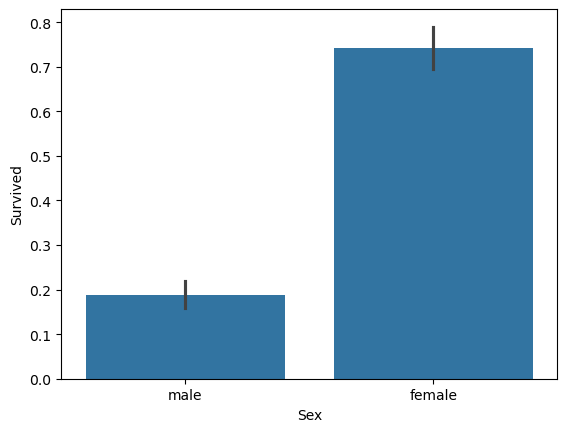

In [46]:
sns.barplot(x='Sex', y = 'Survived', data=titanic_df)

<Axes: xlabel='Pclass', ylabel='Survived'>

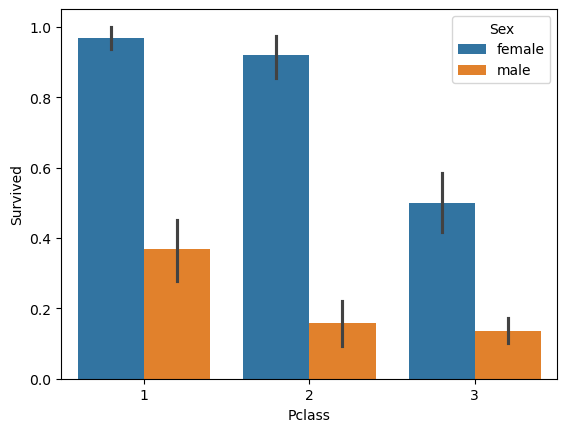

In [47]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df)

###  타이타닉 데이터 로딩 및 기본 확인

- `pd.read_csv()`를 사용하여 타이타닉 학습 데이터를 불러옴
- `head(3)`을 통해 상위 3개의 데이터를 확인하여 데이터 구조를 파악
- `info()`를 통해 각 컬럼의 데이터 타입과 결측치 여부를 확인

---

### 📌 결측치 처리

- `Age` 컬럼의 결측치는 평균값으로 대체
- `Cabin` 컬럼의 결측치는 `'N'`으로 대체
- `Embarked` 컬럼의 결측치도 `'N'`으로 대체

 결측치를 처리한 뒤 전체 Null 값 개수를 다시 확인하여 누락 데이터가 없는지 검증

---

###  범주형 데이터 분포 확인

- `value_counts()`를 사용하여 주요 범주형 변수의 값 분포를 확인
  - `Sex`
  - `Cabin`
  - `Embarked`

 각 범주형 변수에 어떤 값들이 얼마나 존재하는지 파악 가능

---

###  Cabin 데이터 가공

- `Cabin` 값은 보통 `C85`, `E46`처럼 알파벳+숫자 형태로 구성됨
- 여기서 앞 글자만 추출하여 객실 등급 문자만 남김

 복잡한 객실 번호를 단순화하여 분석에 활용하기 쉽게 변환

---

###  생존자 수 그룹 분석

- `groupby(['Sex','Survived'])['Survived'].count()`를 통해  
  성별과 생존 여부에 따른 인원 수를 집계

 어떤 성별이 더 많이 생존했는지 확인 가능

---

###  시각화

- `sns.barplot(x='Sex', y='Survived', data=titanic_df)`  
   성별에 따른 평균 생존율 시각화

- `sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df)`  
   객실 등급과 성별에 따른 생존율 시각화

 성별과 객실 등급이 생존율에 어떤 영향을 주는지 직관적으로 확인 가능

---

###  핵심 정리

- 데이터 분석의 첫 단계는  
   **데이터 구조 확인 → 결측치 처리 → 범주형 분포 확인 → 시각화**

- 타이타닉 데이터에서는  
  👉`Sex`, `Pclass`, `Cabin`, `Embarked` 같은 범주형 변수가 중요한 의미를 가질 수 있음

- 시각화를 통해 단순 숫자 확인보다 더 쉽게 패턴을 파악할 수 있음



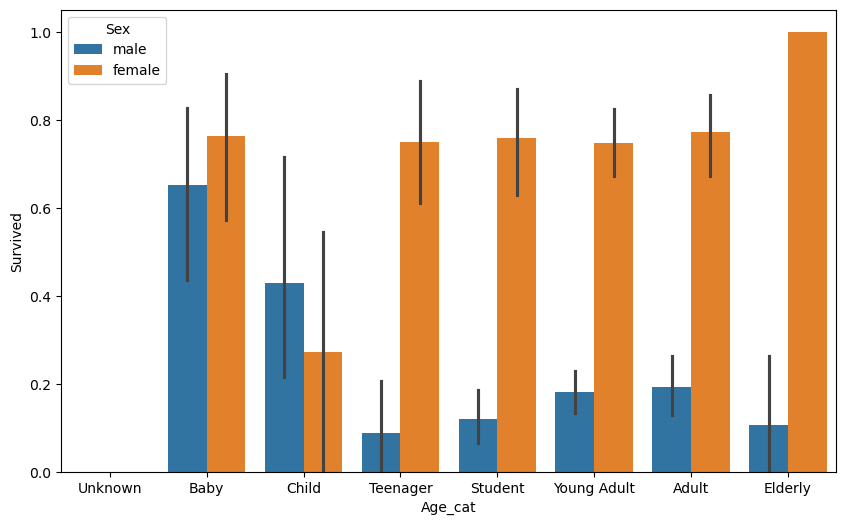

In [50]:
# 입력 age에 따라 구분값을 반환하는 함수 설정. DataFrame의 apply lambda식에 사용. 
def get_category(age):
    cat = ''
    if age <= -1: cat = 'Unknown'
    elif age <= 5: cat = 'Baby'
    elif age <= 12: cat = 'Child'
    elif age <= 18: cat = 'Teenager'
    elif age <= 25: cat = 'Student'
    elif age <= 35: cat = 'Young Adult'
    elif age <= 60: cat = 'Adult'
    else : cat = 'Elderly'
    
    return cat

# 막대그래프의 크기 figure를 더 크게 설정 
plt.figure(figsize=(10,6))

#X축의 값을 순차적으로 표시하기 위한 설정 
group_names = ['Unknown', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Elderly']

# lambda 식에 위에서 생성한 get_category( ) 함수를 반환값으로 지정. 
# get_category(X)는 입력값으로 'Age' 컬럼값을 받아서 해당하는 cat 반환
titanic_df['Age_cat'] = titanic_df['Age'].apply(lambda x : get_category(x))
sns.barplot(x='Age_cat', y = 'Survived', hue='Sex', data=titanic_df, order=group_names)
titanic_df.drop('Age_cat', axis=1, inplace=True)

In [51]:
from sklearn import preprocessing

def encode_features(dataDF):
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = preprocessing.LabelEncoder()
        le = le.fit(dataDF[feature])
        dataDF[feature] = le.transform(dataDF[feature])
        
    return dataDF

titanic_df = encode_features(titanic_df)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,7,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,7,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2,3
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,7,3


In [52]:
from sklearn.preprocessing import LabelEncoder

# Null 처리 함수
def fillna(df):
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    df['Cabin'].fillna('N', inplace=True)
    df['Embarked'].fillna('N', inplace=True)
    df['Fare'].fillna(0, inplace=True)
    return df

# 머신러닝 알고리즘에 불필요한 피처 제거
def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df

# 레이블 인코딩 수행.
def format_features(df):
    df['Cabin'] = df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

# 앞에서 설정한 데이터 전처리 함수 호출
def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

### 나이(Age) 기반 범주화 함수

- `get_category(age)` 함수는 나이를 여러 구간으로 나누어 **범주형 변수로 변환**
  - Baby, Child, Teenager, Student, Adult 등으로 구분

 연속형 데이터를 범주형 데이터로 변환하여 패턴을 더 쉽게 분석 가능

---

###  Label Encoding 함수 (encode_features)

- `Cabin`, `Sex`, `Embarked` 컬럼을 숫자로 변환
- `LabelEncoder`를 사용하여 문자열 데이터를 정수형으로 인코딩

 머신러닝 모델이 처리할 수 있도록 데이터 형태 변환

---

###  Age 기반 시각화

- `Age` 데이터를 `Age_cat`으로 변환 후  
  나이대별 생존율을 시각화

- `sns.barplot()`을 통해:
  - x축: 나이 그룹
  - y축: 생존율
  - hue: 성별

 나이와 성별에 따른 생존 패턴을 직관적으로 확인 가능

---

###  결측치 처리 함수 (fillna)

- 주요 컬럼의 결측치를 다음과 같이 처리:
  - `Age` → 평균값
  - `Cabin`, `Embarked` → 'N'
  - `Fare` → 0

 데이터 누락으로 인한 모델 오류 방지

---

###  불필요한 피처 제거 (drop_features)

- 모델 학습에 필요 없는 컬럼 제거
  - `PassengerId`, `Name`, `Ticket`

모델 성능 저하 및 노이즈 제거

---

###  피처 가공 (format_features)

- `Cabin` → 첫 글자만 추출 (객실 등급 단순화)
- `Cabin`, `Sex`, `Embarked` → Label Encoding 수행

 범주형 데이터를 모델 입력 형태로 변환

---

###  전체 전처리 파이프라인 (transform_features)

- 여러 전처리 과정을 하나로 묶은 함수
  1. 결측치 처리 (`fillna`)
  2. 불필요 피처 제거 (`drop_features`)
  3. 인코딩 (`format_features`)

 한 번의 호출로 전체 전처리 수행 가능

---

###  핵심 정리

- Feature Engineering은  
   데이터를 모델이 잘 학습할 수 있는 형태로 변환하는 과정

- 좋은 전처리는  
   모델 성능에 직접적인 영향을 줌

- 함수로 구조화하면  
   재사용성과 코드 관리가 쉬워짐




In [53]:
# 원본 데이터를 재로딩 하고, feature데이터 셋과 Label 데이터 셋 추출. 
titanic_df = pd.read_csv('./titanic_train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df= titanic_df.drop('Survived',axis=1)

X_titanic_df = transform_features(X_titanic_df)


/var/folders/vr/slsqd_zj5p9bxc23hrt26xjw0000gn/T/ipykernel_84525/340051843.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/var/folders/vr/slsqd_zj5p9bxc23hrt26xjw0000gn/T/ipykernel_84525/340051843.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

In [54]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X_titanic_df, y_titanic_df, \
                                                  test_size=0.2, random_state=11)


In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 결정트리, Random Forest, 로지스틱 회귀를 위한 사이킷런 Classifier 클래스 생성
dt_clf = DecisionTreeClassifier(random_state=11)
rf_clf = RandomForestClassifier(random_state=11)
lr_clf = LogisticRegression(solver='liblinear')

# DecisionTreeClassifier 학습/예측/평가
dt_clf.fit(X_train , y_train)
dt_pred = dt_clf.predict(X_test)
print('DecisionTreeClassifier 정확도: {0:.4f}'.format(accuracy_score(y_test, dt_pred)))

# RandomForestClassifier 학습/예측/평가
rf_clf.fit(X_train , y_train)
rf_pred = rf_clf.predict(X_test)
print('RandomForestClassifier 정확도:{0:.4f}'.format(accuracy_score(y_test, rf_pred)))

# LogisticRegression 학습/예측/평가
lr_clf.fit(X_train , y_train)
lr_pred = lr_clf.predict(X_test)
print('LogisticRegression 정확도: {0:.4f}'.format(accuracy_score(y_test, lr_pred)))


DecisionTreeClassifier 정확도: 0.7877
RandomForestClassifier 정확도:0.8547
LogisticRegression 정확도: 0.8659
